In [1]:
from qiskit import *
import random

In [4]:
def gerar_indices_subconjuntos(k, total_bits):
    """
    Gera k subconjuntos aleatórios contendo os índices dos qubits.
    
    Args:
        k (int): Número de subconjuntos (amostras).
        total_bits (int): O número total de qubits de controle (ex: 99).
        
    Returns:
        list: Uma lista de listas, onde cada sublista contém os índices 
              dos qubits (de 0 a total_bits-1) escolhidos para aquele subconjunto.
    """
    qubits_disponiveis = list(range(total_bits))
    matriz_indices = []
    
    for _ in range(k):
        # Para cada subconjunto, decide-se para cada qubit se ele entra ou não (50% de chance).
        # Isso garante a amostragem uniforme de todos os subconjuntos possíveis[cite: 86, 88].
        subconjunto = [i for i in qubits_disponiveis if random.random() < 0.5]
        matriz_indices.append(subconjunto)
        
    return matriz_indices

In [ ]:
k = 4
n_bits = 99
subconjuntos = gerar_indices_subconjuntos(k, n_bits)

# Exibindo os subconjuntos gerados
for i, s in enumerate(subconjuntos):
    print(f"Subconjunto S{i+1} (contém {len(s)} qubits): {s}... (mostrando apenas os 10 primeiros)")

Subconjunto S1 (contém 52 qubits): [0, 2, 3, 6, 7, 11, 12, 13, 15, 18, 21, 23, 25, 27, 29, 31, 32, 33, 35, 36, 39, 40, 44, 45, 46, 47, 48, 49, 51, 53, 56, 59, 62, 66, 67, 70, 74, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 89, 90, 91, 92, 94]... (mostrando apenas os 10 primeiros)
Subconjunto S2 (contém 51 qubits): [0, 3, 6, 8, 9, 10, 11, 12, 13, 14, 21, 22, 24, 25, 26, 27, 28, 30, 31, 32, 33, 34, 41, 44, 47, 51, 52, 54, 57, 58, 61, 64, 65, 66, 67, 70, 73, 74, 75, 77, 79, 80, 82, 85, 86, 89, 90, 92, 96, 97, 98]... (mostrando apenas os 10 primeiros)
Subconjunto S3 (contém 48 qubits): [2, 5, 8, 10, 11, 12, 15, 19, 21, 24, 25, 30, 31, 32, 33, 34, 35, 39, 40, 42, 43, 45, 47, 48, 50, 54, 56, 59, 61, 63, 64, 68, 70, 73, 74, 76, 78, 79, 82, 83, 85, 89, 91, 92, 93, 95, 96, 98]... (mostrando apenas os 10 primeiros)
Subconjunto S4 (contém 46 qubits): [1, 7, 8, 10, 11, 12, 15, 17, 24, 25, 28, 29, 31, 32, 33, 34, 35, 36, 38, 41, 43, 45, 47, 48, 50, 51, 52, 53, 57, 59, 60, 65, 74, 75, 79, 82, 83, 84, 85

In [13]:
def parity_check(bits: int) -> QuantumCircuit:
    """
    Implementa um check de paridade de "bits"-bits, o resultado é registrado num bit extra ao final
    operação: se no de bits 1 é par, parity=0, se ímpar, parity=1
    """

    qc = QuantumCircuit(bits+1)
    qc.name = "parity_check"
    for i in range(bits):
        qc.cx(i, bits)

    return qc

In [12]:
def compose_toff_optimization(bits: int, k: int) -> QuantumCircuit:
    reg_controls = QuantumRegister(bits-1, name="controls")
    reg_xor_anc = QuantumRegister(k, name="xor_anc")
    reg_last_bit = QuantumRegister(1, name="last_bit")
    quantum_circuit = QuantumCircuit(reg_controls, reg_xor_anc, reg_last_bit)

    subset_matrix = gerar_indices_subconjuntos(k, bits)

    for i, subset in enumerate(subset_matrix):
        quantum_circuit.append(parity_check(len(subset)), subset[:] + reg_xor_anc[i:i+1])
    
    quantum_circuit.mcx(reg_xor_anc[:], reg_last_bit[:])

    return quantum_circuit

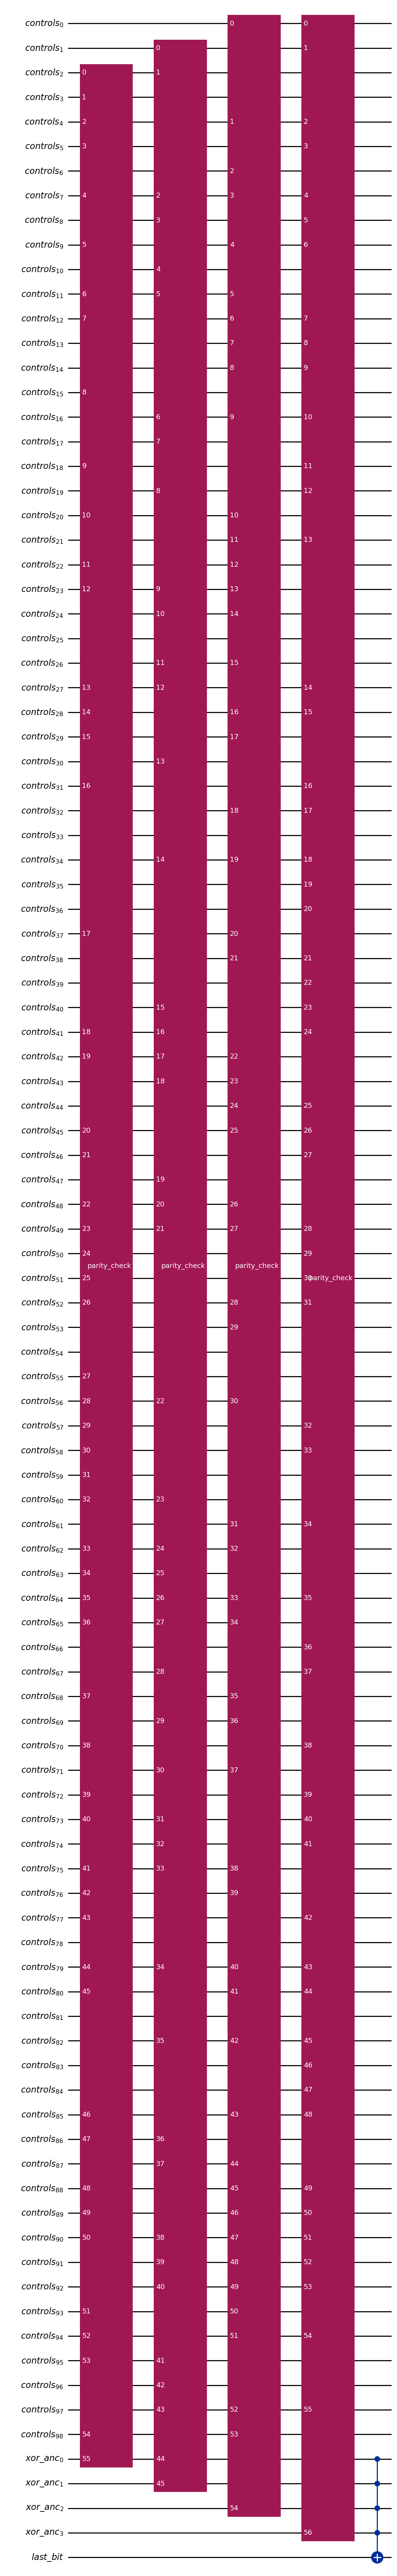

In [14]:
compose_toff_optimization(100, 4).draw("mpl")